## Bài toán:


> **Đánh giá điểm tín dụng sử dụng Decision Tree và Random Forest**

Mục tiêu:

- Xây dựng mô hình Decision Tree và Random Forest sử dụng thư viện sklearn.
- Áp dụng hai mô hình để giải bài toán thực tế (đánh giá điểm tín dụng).
- Sử dụng độ đo thích hợp để đánh giá chất lượng mô hình.

Vấn đề:

- Trong lĩnh vực tài chính, bài toán đánh giá tín dụng của người dùng là bài toán phổ biến và quan trọng. Ở đó, ngân hàng sẽ xác định liệu có cho một người dùng nào đó thực hiện khoản vay hay không, dựa trên thông tin về điểm tín dụng. Điểm tín dụng chính là con số phản ánh khả năng hoàn trả của người vay. Nhìn chung, đây là một bài toán phân lọai 2 lớp (good/bad score).
- Ngoài ra, một vấn đề thường gặp phải trong bài toán này đó: số lượng bad credits thường ít hơn nhiều so với số lượng good credits ==> Dữ liệu nhãn lớp mất cân bằng.

Dữ liệu:

- Cho dưới dạng bảng, mỗi hàng là một cá nhân vay, mỗi cột thể hiện một thuộc tính của cá nhân đó.
- Các trường thuộc tính tồn tại ở nhiều dạng: categorical, numeric (discrete / continuous). Thậm chí tên trường có thể được ẩn đi, hay giá trị thật sự được mã hõa để đảm bảo tính bảo mật của khách hàng.
- Hai tập dữ liệu sẽ sử dụng: [German credit](https://archive.ics.uci.edu/ml/datasets/Statlog+%28German+Credit+Data%29) và [Australian credit.](https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)


Mô hình hóa bài toán: bài toán phân loại nhị phân

- Đâu vào: $N$ vector $D$ chiều (ma trận cỡ $N \times D$), tương ứng $N$ cá thể với $D$ thuộc tính.
- Đầu ra: nhãn $0-1$ (0: bad credit, 1: good credit).

## Các bước thực hiện

### Import các thư viện cần thiết

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

random_state = 42

### Tìm hiểu dữ liệu

In [17]:
'''
- Tìm hiểu cấu trúc data tại trang web UCI
- Down các files, đặt trong folder data/
- Làm với phiên bản 'numeric'
'''
data_path = './data/german.data-numeric'
credit=np.genfromtxt(data_path)
print(credit)
X,y = credit[:,:-1], credit[:,-1]
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


[[ 1.  6.  4. ...  0.  1.  1.]
 [ 2. 48.  2. ...  0.  1.  2.]
 [ 4. 12.  4. ...  1.  0.  1.]
 ...
 [ 4. 12.  2. ...  0.  1.  1.]
 [ 1. 45.  2. ...  0.  1.  2.]
 [ 2. 45.  4. ...  0.  1.  1.]]
(1000, 24) (1000,)
(800, 24) (200, 24)


In [18]:
print(len(y))

1000


### Khởi tạo các mô hình Decision Tree, Random Forest của Sklearn

In [19]:
'''
- Decision Tree
https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
'''
DT = DecisionTreeClassifier(random_state=random_state)

'''
- Random Forest
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
'''
RF = RandomForestClassifier(random_state=random_state)

In [37]:

DT.fit(X_train, y_train)
y_dt_pred = DT.predict(X_test)
print("-DT acc = {}".format(accuracy_score(y_test, y_dt_pred)))
print("-DT f1 = {}".format(f1_score(y_test, y_dt_pred)))
print("-DT roc auc = {}".format(roc_auc_score(y_test, y_dt_pred)))
print(confusion_matrix(y_test, y_dt_pred))

-DT acc = 0.665
-DT f1 = 0.7632508833922261
-DT roc auc = 0.5948431301839163
[[108  33]
 [ 34  25]]


##### Bài 1: Chạy RF baseline

In [38]:
# code
RF.fit(X_train, y_train)
y_dt_pred = RF.predict(X_test)
print("-DT acc = {}".format(accuracy_score(y_test, y_dt_pred)))
print("-DT f1 = {}".format(f1_score(y_test, y_dt_pred)))
print("-DT roc auc = {}".format(roc_auc_score(y_test, y_dt_pred)))
print(confusion_matrix(y_test, y_dt_pred))

-DT acc = 0.81
-DT f1 = 0.875
-DT roc auc = 0.7173939175381656
[[133   8]
 [ 30  29]]


### Tìm kiếm siêu tham số

In [22]:
# Một số hàm hỗ trợ
def grid_search(algorithm, n_jobs, dict_param):
    if algorithm == 'decision-tree':
        model = DecisionTreeClassifier()
    if algorithm == 'random-forest':
        model = RandomForestClassifier()
    classifier = GridSearchCV(estimator=model, cv=5, param_grid=dict_param,
                            n_jobs=n_jobs, scoring='f1')
    classifier.fit(X_train, y_train)
    print('Best model', end='')
    print(classifier.best_estimator_)
    return classifier.best_estimator_

def evaluate(model):
    print("Train Accuracy :", accuracy_score(y_train, model.predict(X_train)))
    print("Train f1 score :", f1_score(y_train, model.predict(X_train)))
    print("Train roc auc :", roc_auc_score(y_train, model.predict(X_train)))
    print("Train Confusion Matrix:")
    print(confusion_matrix(y_train, model.predict(X_train)))
    print("-"*50)
    print("Test Accuracy :", accuracy_score(y_test, model.predict(X_test)))
    print("Test f1 score :", f1_score(y_test, model.predict(X_test)))
    print("Test roc auc :", roc_auc_score(y_test, model.predict(X_test)))
    print("Test Confusion Matrix:")
    print(confusion_matrix(y_test, model.predict(X_test)))

def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5), new_plot=False,
                        idx_color=0):
    # Khởi tạo bức ảnh mới với thư viện plot lib
    if new_plot:
        # plt.figure()
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Score")
        plt.grid()
    # chú thích nếu có
    if ylim is not None:
        plt.ylim(*ylim)

    # thực hiện training model, ghi nhận các giá trị trong quá trình training
    # cv = số fold cross validate, số phần bộ dữ liệu được chia để thực hiện training testing.
    # train_sizes = mảng tỉ lệ, các tỉ lệ được hệ thống chọn làm điểm dừng để thực hiện 1 testing
    #  train_sizes = [0.3, 0.5] => hệ thống lấy 30 % dữ liệu để train và thực hiện test, tương tự 50 % ..
    # scoring = hàm mục tiêu để đánh giá chất lượng mô hình và vẽ lên đồ thị
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="f1")
    # Lấy trung bình cộng các giá trị output của các fold
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # thực hiện vẽ các giá trị số lên đồ thị với màu vừa được random
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color='r')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color='g')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='r',
             label=label_curve['test'])
    plt.plot(train_sizes, train_scores_mean, 'o-', color='g',
             label=label_curve['train'])

    plt.legend(loc="best")
    return plt

#### Decision Tree

Text(0.5, 1.0, 'DT validation curve for max_depth')

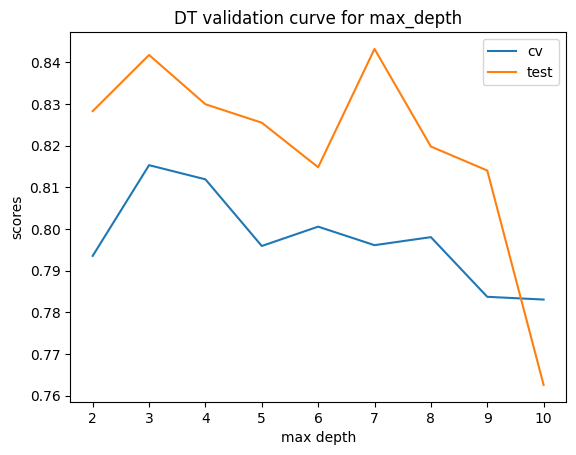

In [23]:
# Trước hết, hãy thử khảo sát DT với tham số max_depth
cv_accuracies_by_depth, test_accuracies_by_depth= [], []
max_depth_values= np.arange(2,11)

for curr_max_depth in max_depth_values:
  tree= DecisionTreeClassifier(random_state=random_state, max_depth=curr_max_depth)

  # cross-validation
  val_scores= cross_val_score(estimator=tree, X=X_train, y=y_train, cv=5, scoring='f1')
  cv_accuracies_by_depth.append(val_scores.mean())

  # test
  tree.fit(X_train, y_train)
  curr_pred= tree.predict(X_test)
  test_accuracies_by_depth.append(f1_score(curr_pred, y_test))

# Plot
plt.plot(max_depth_values, cv_accuracies_by_depth, label='cv')
plt.plot(max_depth_values, test_accuracies_by_depth, label='test')
plt.legend()
plt.xlabel('max depth')
plt.ylabel('scores')
plt.title('DT validation curve for max_depth')

In [24]:
# Thử sử dụng GridSearchCV để khảo sát
dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('decision-tree', n_jobs=-1, dict_param=dict_param)


Best modelDecisionTreeClassifier(max_depth=5, min_samples_leaf=20)


##### Bài 2: đánh giá best_tree
- Prediction performance
- Learning curve

Train Accuracy : 0.77125
Train f1 score : 0.8473728106755629
Train roc auc : 0.680523905314024
Train Confusion Matrix:
[[508  51]
 [132 109]]
--------------------------------------------------
Test Accuracy : 0.78
Test f1 score : 0.8533333333333334
Test roc auc : 0.6911888448130785
Test Confusion Matrix:
[[128  13]
 [ 31  28]]


<module 'matplotlib.pyplot' from '/usr/local/Caskroom/miniconda/base/envs/course/lib/python3.12/site-packages/matplotlib/pyplot.py'>

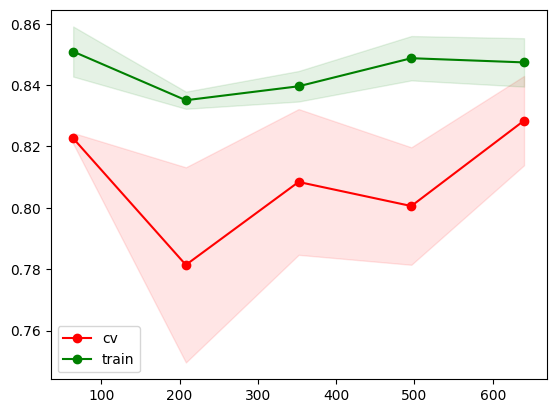

In [25]:
# code
best_tree.fit(X_train, y_train)
evaluate(best_tree)

title = 'Learning curve with best tree'
label_curve = {'train': 'train', 'test':'cv'}
plot_learning_curve(best_tree, title, label_curve
                    , X_train, y_train, cv=5)


Top 10 feature importances
Feature  0 - 0.40445005922715943
Feature  1 - 0.17066428015343657
Feature  2 - 0.14261352910286315
Feature  3 - 0.07120344185816782
Feature  4 - 0.05428847945598893
Feature  5 - 0.05400258515142507
Feature  6 - 0.04007488290946428
Feature  7 - 0.03813781829612112
Feature  8 - 0.015091674891623292
Feature  9 - 0.009473248953750433


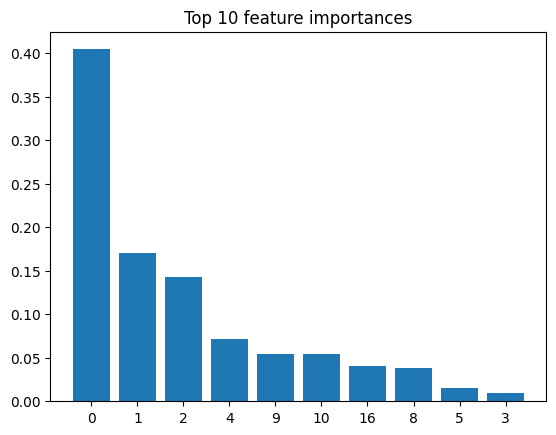

In [39]:
# Nhận xét về độ quan trọng của từng feature
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
print('Top 10 feature importances')
for i in range(10):
    print('Feature ', i, '-', importances[indices[i]])

indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices])
plt.xticks(range(10), indices)
plt.show()

#### Random Forest

##### Bài 3: thực hành tương tự với RF

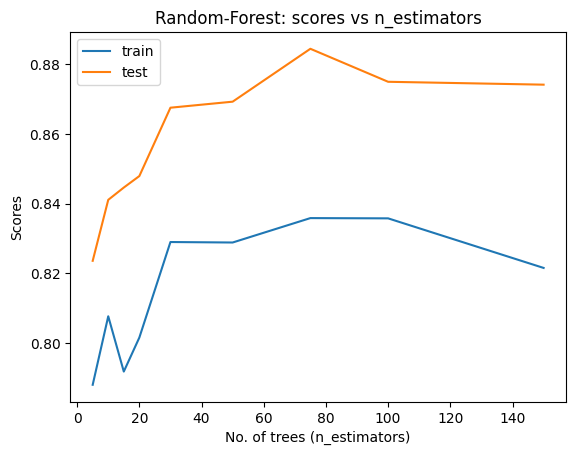

In [27]:
# Bài tập
# Tương tự, thử khảo sát RF với số lượng cây n_estimators
# code
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]

train_acc = []
test_acc = []
for ntrees in num_trees:
    rf = RandomForestClassifier(n_estimators=ntrees, random_state=random_state, n_jobs=-1).fit(X_train, y_train)
    temp_train_acc=cross_val_score(rf, X_test, y_test, cv=5, scoring='f1')
    train_acc.append(temp_train_acc.mean())
    test_acc.append(f1_score(rf.predict(X_test), y_test))
plt.plot(num_trees, train_acc, label='train')
plt.plot(num_trees, test_acc, label='test')
plt.legend()
plt.xlabel('No. of trees (n_estimators)')
plt.ylabel('Scores')
plt.title('Random-Forest: scores vs n_estimators');



In [40]:
# Sử dụng GridSearch CV
dict_param = {
    'max_depth': [3, 11, 15, 24, 27],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features':  [4, 6, 10, 16],
    'n_estimators': [75]
}
# Bài tập:
# - tìm best_forest
# - Đánh giá best_forest
# - Vẽ learning curve
# - Tìm hiểu feature importance
# Code

# - Tìm best_forest
best_forest = grid_search('random-forest', n_jobs=-1, dict_param=dict_param)

Best modelRandomForestClassifier(max_depth=27, max_features=10, min_samples_leaf=5,
                       n_estimators=75)


Train Accuracy : 0.8925
Train f1 score : 0.9276094276094277
Train roc auc : 0.8310186387963093
Train Confusion Matrix:
[[551   8]
 [ 78 163]]
--------------------------------------------------
Test Accuracy : 0.815
Test f1 score : 0.8810289389067524
Test roc auc : 0.7061545858877268
Test Confusion Matrix:
[[137   4]
 [ 33  26]]


<module 'matplotlib.pyplot' from '/usr/local/Caskroom/miniconda/base/envs/course/lib/python3.12/site-packages/matplotlib/pyplot.py'>

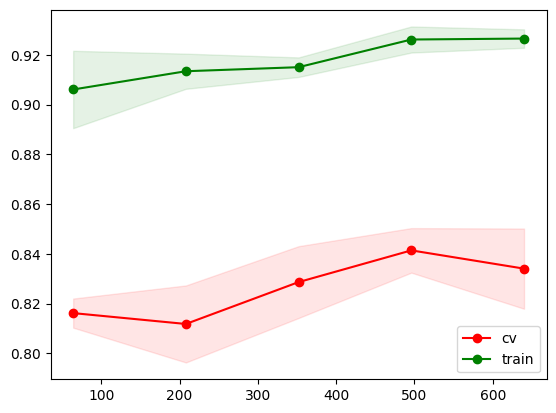

In [41]:
# Code
# - Đánh giá best_forest và vẽ Learning Curve
best_forest.fit(X_train, y_train)
evaluate(best_forest)

title = 'Learning curve with best tree'
label_curve = {'train': 'train', 'test':'cv'}
plot_learning_curve(best_forest, title, label_curve
                    , X_train, y_train, cv=5)

Top 10 feature importances
Feature  0 - 0.172076776724566
Feature  1 - 0.14213314836910368
Feature  2 - 0.11724599608372238
Feature  3 - 0.11115116796961577
Feature  4 - 0.09195435324027859
Feature  5 - 0.05141051128168885
Feature  6 - 0.04314365980553882
Feature  7 - 0.043017757165498265
Feature  8 - 0.033174192695694
Feature  9 - 0.03313497289802168


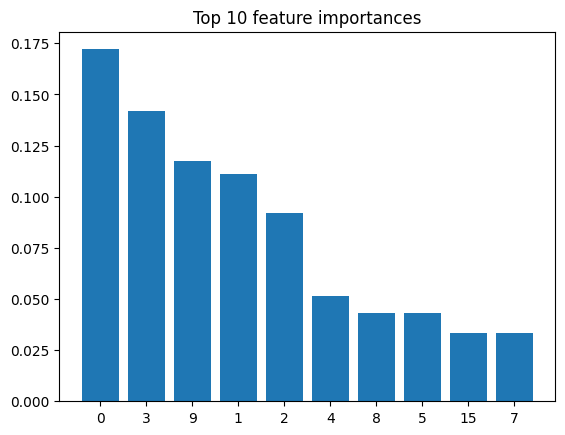

In [42]:
# Code: Feature importance

# Nhận xét về độ quan trọng của từng feature
importances = best_forest.feature_importances_
indices = np.argsort(importances)[::-1]

print('Top 10 feature importances')
for i in range(10):
    print('Feature ', i, '-', importances[indices[i]])

indices = indices[:10]
plt.figure()
plt.title('Top 10 feature importances')
plt.bar(range(10), importances[indices])
plt.xticks(range(10), indices)
plt.show()


### Thử nghiệm bổ sung

#### Bỏ một số features có độ quan trọng thấp

In [31]:
# Thử bỏ một sô feature có độ quan trọng thấp đi
# Chú ý tham max_features cần thay đổi
sfm = SelectFromModel(best_forest, threshold='mean')
sfm.fit(X_train, y_train)
X_train_dropped = sfm.transform(X_train)
X_test_dropped = sfm.transform(X_test)

title = 'Learning with dropped features'
label_curve = {'train': 'train', 'test':'cv'}
forest_dropped = RandomForestClassifier(max_depth=11, min_samples_leaf=5,
                       n_estimators=75, n_jobs=-1, random_state=random_state)

# plot_learning_curve(forest_dropped, title, label_curve, X_train_dropped, y_train, cv=5)

forest_dropped.fit(X_train_dropped, y_train)
y_dropped_pred = forest_dropped.predict(X_test_dropped)
print('acc', accuracy_score(y_test, y_dropped_pred))
print('f1', f1_score(y_test, y_dropped_pred))
print('roc_auc', roc_auc_score(y_test, y_dropped_pred))

acc 0.805
f1 0.8737864077669902
roc_auc 0.6990623873061665


#### Một số chiến lược áp dụng cho Random Forest khi gặp phải Class Imbalance
https://machinelearningmastery.com/bagging-and-random-forest-for-imbalanced-classification/

In [32]:
'''
- Standard RF
'''
params = {
    'max_depth': best_forest.get_params()['max_depth'],
    'max_features': best_forest.get_params()['max_features'],
    'min_samples_leaf': best_forest.get_params()['min_samples_leaf'],
    'n_estimators': best_forest.get_params()['n_estimators'],
}
evaluate(best_forest)


Train Accuracy : 1.0
Train f1 score : 1.0
Train roc auc : 1.0
Train Confusion Matrix:
[[559   0]
 [  0 241]]
--------------------------------------------------
Test Accuracy : 0.81
Test f1 score : 0.8707482993197279
Test roc auc : 0.7420363024401971
Test Confusion Matrix:
[[128  13]
 [ 25  34]]


In [33]:
'''
- Random Forest With Class Weighting
'''
rf1 = RandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             class_weight='balanced')
rf1.fit(X_train, y_train)
evaluate(rf1)

Train Accuracy : 1.0
Train f1 score : 1.0
Train roc auc : 1.0
Train Confusion Matrix:
[[559   0]
 [  0 241]]
--------------------------------------------------
Test Accuracy : 0.795
Test f1 score : 0.8655737704918033
Test roc auc : 0.6968986657050127
Test Confusion Matrix:
[[132   9]
 [ 32  27]]


In [34]:
'''
- Random Forest With Bootstrap Class Weighting
'''
'''
- Random Forest With Class Weighting
'''
rf2 = RandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             class_weight='balanced_subsample')
rf2.fit(X_train, y_train)
evaluate(rf2)

Train Accuracy : 1.0
Train f1 score : 1.0
Train roc auc : 1.0
Train Confusion Matrix:
[[559   0]
 [  0 241]]
--------------------------------------------------
Test Accuracy : 0.785
Test f1 score : 0.86084142394822
Test roc auc : 0.6750210361822335
Test Confusion Matrix:
[[133   8]
 [ 35  24]]


In [44]:
'''
- Random Forest With Random Undersampling
'''
from imblearn.ensemble import BalancedRandomForestClassifier
rf3 = BalancedRandomForestClassifier(max_depth=params['max_depth'], max_features=params['max_features'],
                             min_samples_leaf = params['min_samples_leaf'], n_estimators=params['n_estimators'],
                             )
rf3.fit(X_train, y_train)
evaluate(rf3)

Train Accuracy : 0.9775
Train f1 score : 0.9836363636363636
Train roc auc : 0.9838998211091234
Train Confusion Matrix:
[[541  18]
 [  0 241]]
--------------------------------------------------
Test Accuracy : 0.785
Test f1 score : 0.8436363636363636
Test roc auc : 0.7588051448491405
Test Confusion Matrix:
[[116  25]
 [ 18  41]]
